
# 🌳 FINAL PREMIUM NOTEBOOK – Decision Trees (Advanced Concepts)

This notebook continues the premium series with deeper understanding of:

- Decision Boundary
- Important Hyperparameters
- Advantages & Limitations

Focus:
- Deep intuition
- Interview readiness
- Real-world (BFSI) mapping
- Visual + conceptual clarity

---


# 📊 Decision Boundary (Deep Intuition)
---

## 🧠 Explanation
Decision Boundary represents how a model separates different classes in feature space.

In Decision Trees, boundaries are created using axis-aligned splits. This means splits happen
parallel to feature axes, resulting in rectangular regions.

Unlike models like Logistic Regression (linear boundary) or SVM (smooth boundary),
Decision Trees create step-like, blocky regions. This makes them highly flexible but also prone
to overfitting when too many splits are created.

You should visualize trees as partitioning space into boxes, not lines.

## 📐 Formula / Technical View
No single formula. Boundary is created through recursive splits.

## 🏦 Real-Life Use Case
In fraud detection, the model may say:
If transaction_amount < X AND time < Y → Not Fraud
Else → Fraud

This creates box-like regions in data space.

## ⚠️ Limitation
Boundaries are not smooth → poor generalization in some cases.

## 🔄 Comparison / Types
Decision Tree vs Logistic Regression vs SVM boundaries

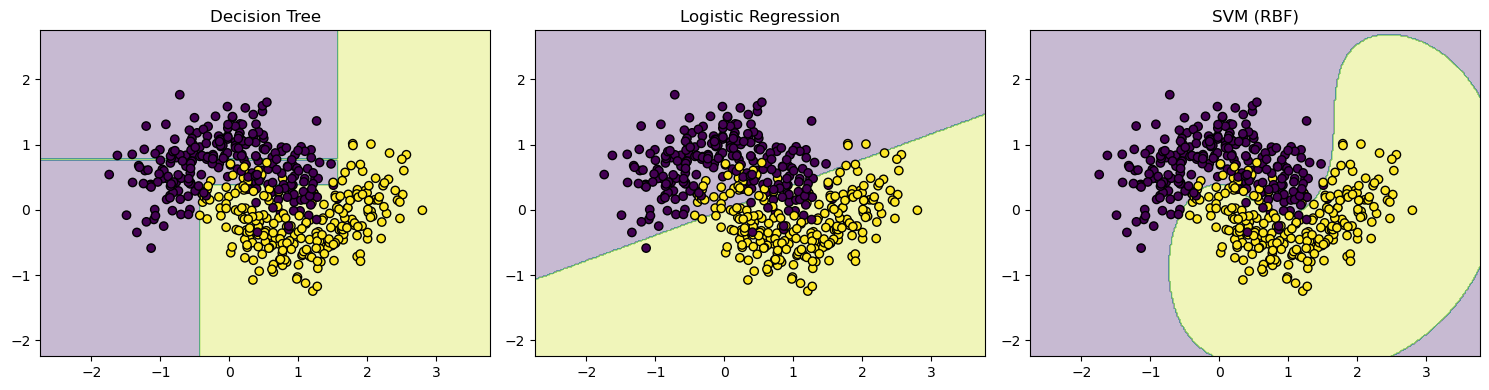

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 🔹 Step 1: Create non-linear dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# 🔹 Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 3: Models
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4),
    "Logistic Regression": LogisticRegression(),
    "SVM (RBF)": SVC(kernel='rbf', probability=True)
}

# 🔹 Step 4: Function to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)

# 🔹 Step 5: Train + Plot
plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    
    plt.subplot(1, 3, i+1)
    plot_decision_boundary(model, X, y, name)

plt.tight_layout()
plt.show()

---

In [3]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))


Decision Tree
Accuracy: 0.88
F1 Score: 0.8947368421052632
ROC AUC: 0.9447164422684619

Logistic Regression
Accuracy: 0.85
F1 Score: 0.8571428571428571
ROC AUC: 0.9510403916768666

SVM (RBF)
Accuracy: 0.87
F1 Score: 0.8712871287128713
ROC AUC: 0.9759281925744594


# ⚙️ Important Hyperparameters (Deep Control of Tree)
---

## 🧠 Explanation
Hyperparameters control how a Decision Tree grows.

max_depth limits how deep the tree can grow. This directly controls model complexity.
min_samples_split defines the minimum number of samples required to split a node.
min_samples_leaf ensures that each leaf has enough samples, preventing very small nodes.
max_features controls how many features are considered at each split, adding randomness.

These parameters are critical because Decision Trees are naturally prone to overfitting.
Proper tuning helps balance bias and variance.

## 📐 Formula / Technical View
No single formula. These are constraints applied during training.

## 🏦 Real-Life Use Case
In credit risk modeling:
- Shallow tree → misses risky patterns
- Deep tree → overfits historical data

Hyperparameters help balance this.

## ⚠️ Limitation
Requires tuning. No universal best values.

## 🔄 Comparison / Types
Hyperparameters vs Regularization in Linear Models

In [5]:
# 🔹 Step 1: Import
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 🔹 Step 2: Initialize model
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)

# 🔹 Step 3: Train model
model.fit(X_train, y_train)

# 🔹 Step 4: Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 🔹 Step 5: Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[42  1]
 [ 8 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.90        43
           1       0.98      0.86      0.92        57

    accuracy                           0.91       100
   macro avg       0.91      0.92      0.91       100
weighted avg       0.92      0.91      0.91       100


ROC AUC Score: 0.9385964912280702


In [6]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


---

In [8]:
# Convert back to DataFrame
X_train = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])

importance = pd.Series(model.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False))

feature_1    0.517241
feature_0    0.482759
dtype: float64


# ✅❌ Advantages & Limitations (Critical Thinking)
---

## 🧠 Explanation
Decision Trees are popular because they are intuitive and powerful.

They do not require feature scaling and can handle non-linear relationships naturally.
They are also interpretable, which is very important in domains like banking.

However, they have serious drawbacks. They overfit easily, are unstable, and small changes
in data can produce very different trees. This is why in real-world systems,
they are rarely used alone and are combined into ensemble models.

## 📐 Formula / Technical View
Not formula-based concept

## 🏦 Real-Life Use Case
In BFSI:
- Advantage: Easy to explain to regulators (important)
- Limitation: Unstable → not reliable alone for production

## ⚠️ Limitation
High variance, unstable, overfitting

## 🔄 Comparison / Types
Decision Tree vs Random Forest vs Gradient Boosting

# 🌳⚡🌲 Decision Tree vs Random Forest vs Gradient Boosting

---

## 🌳 Decision Tree (Base Model)

### 🧠 Core Idea
- Single tree that splits data using rules (if–else)  
- Greedy algorithm (best split at each step)  

### ⚙️ How it works
- Uses **Gini / Entropy**  
- Recursively splits data  
- Creates **axis-aligned boundaries**  

### ✅ Advantages
- Very easy to understand & explain (business-friendly)  
- No feature scaling needed  
- Handles non-linear data  

### ❌ Limitations
- High overfitting (high variance)  
- Unstable (small data change → different tree)  
- Poor generalization alone  

### 🏦 Use Case
- Rule-based systems (loan approval logic, simple fraud rules)  

---

## 🌲 Random Forest (Bagging Ensemble)

### 🧠 Core Idea
- Combine many decision trees  
- Each tree trained on different data + features  
- Final prediction = **majority vote / average**  

### ⚙️ How it works
- Uses **Bootstrap sampling (bagging)**  
- Uses **feature randomness (`max_features`)**  
- Trees are built independently (**parallel**)  

### ✅ Advantages
- Reduces overfitting (lower variance)  
- More stable than single tree  
- Works well out-of-the-box  

### ❌ Limitations
- Less interpretable than single tree  
- Larger model size  
- Slower than single tree  

### 🏦 Use Case
- Fraud detection  
- Credit risk scoring  
- Customer churn prediction  

---

## ⚡ Gradient Boosting (Boosting Ensemble)

### 🧠 Core Idea
- Build trees sequentially  
- Each new tree fixes errors of previous trees  

### ⚙️ How it works
- Uses **residual learning**  
- Minimizes loss function (gradient descent style)  
- Trees are dependent (**sequential**)  

### ✅ Advantages
- Very high accuracy  
- Captures complex patterns  
- State-of-the-art for tabular data  

### ❌ Limitations
- Prone to overfitting if not tuned  
- Slower training  
- More hyperparameters (complex)  

### 🏦 Use Case
- Fraud detection (advanced)  
- Credit scoring models  
- High-stakes predictive systems  

---

## 🔥 Quick Summary

- 🌳 Decision Tree → Simple, interpretable, but overfits  
- 🌲 Random Forest → Stable, reduces overfitting, good default  
- ⚡ Gradient Boosting → Most powerful, best performance (if tuned)  

---